<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Lab%2016/Lab_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
!pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [2]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7255, 7)
Download successful ✓


In [3]:
# ============================================================
# PART 1B: Build the Analysis Dataset
# ============================================================

# Average over time dimension
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Drop countries with too many missing values (keep countries with >= 60% non-missing)
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators with too many missing values across countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))

# Final fill: impute remaining missing values with the cross-country median
country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

In [4]:
# ============================================================
# PART 1C: Train-Test Split & OLS Baseline
# ============================================================

# Separate outcome (y) from predictors (X)
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]

X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"Training countries: {X_train.shape[0]}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {X_train.shape[1]}")
print(f"Predictor-to-observation ratio (train): p/n = {X_train.shape[1]}/{X_train.shape[0]} = {X_train.shape[1]/X_train.shape[0]:.2f}")
print()
print("If p/n > 0.5, OLS is at serious risk of overfitting.")

# Standardize features (critical for Ridge and Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same transform to test

print("\nFeatures standardized (zero mean, unit variance) ✓")

Training countries: 166
Test countries: 72
Number of predictors: 28
Predictor-to-observation ratio (train): p/n = 28/166 = 0.17

If p/n > 0.5, OLS is at serious risk of overfitting.

Features standardized (zero mean, unit variance) ✓


In [5]:
# ============================================================
# PART 1D: OLS Baseline — Demonstrating the Failure Mode
# ============================================================

ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2  = r2_score(y_train, y_train_pred_ols)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)

# Test performance
y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2  = r2_score(y_test, y_test_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)

print("=" * 45)
print("OLS BASELINE RESULTS")
print("=" * 45)
print(f"Training R²:  {ols_train_r2:.3f}")
print(f"Test R²:      {ols_test_r2:.3f}")
print(f"")
print(f"Training MSE: {ols_train_mse:.3f}")
print(f"Test MSE:     {ols_test_mse:.3f}")
print(f"")
print(f"Gap (Train R² - Test R²): {ols_train_r2 - ols_test_r2:.3f}")
print("=" * 45)
print()
print("Interpretation:")
print(f"  OLS fits the training data {ols_train_r2:.0%} — but only explains")
print(f"  {max(ols_test_r2, 0):.0%} of test variance. This is overfitting.")

OLS BASELINE RESULTS
Training R²:  0.600
Test R²:      -0.849

Training MSE: 2.640
Test MSE:     8.252

Gap (Train R² - Test R²): 1.449

Interpretation:
  OLS fits the training data 60% — but only explains
  0% of test variance. This is overfitting.


In [6]:
# ============================================================
# PART 2A: Ridge Regression with Cross-Validated Lambda
# ============================================================

# Grid of lambda (alpha) values to try — log-spaced from 0.01 to 1000
lambda_grid = np.logspace(-2, 3, 50)

# TODO: Create a RidgeCV with 5-fold CV and the lambda_grid above
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)  # ← complete this line

# TODO: Fit ridge_cv on the scaled training data
ridge_cv.fit(X_train_scaled, y_train)  # ← complete this line

# Evaluate on test set
y_test_pred_ridge = ridge_cv.predict(X_test_scaled)
ridge_test_r2  = r2_score(y_test, y_test_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)

print("=" * 45)
print("RIDGE REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefficients:    {np.sum(ridge_cv.coef_ != 0)} of {X_train.shape[1]}")
print(f"Test R²:                  {ridge_test_r2:.3f}")
print(f"Test MSE:                 {ridge_test_mse:.3f}")
print()
print(f"vs. OLS: Test R² = {ols_test_r2:.3f}, Test MSE = {ols_test_mse:.3f}")

RIDGE REGRESSION RESULTS
Optimal λ* (CV-selected): 47.1487
Non-zero coefficients:    28 of 28
Test R²:                  -0.051
Test MSE:                 4.691

vs. OLS: Test R² = -0.849, Test MSE = 8.252


In [7]:
# ============================================================
# PART 2B: LassoCV — Automated Feature Selection
# ============================================================

def fit_lasso_cv(X_train, y_train, X_test, y_test, cv=5):
    """
    Fit LassoCV to select optimal regularization parameter
    and evaluate on test set.

    Parameters
    ----------
    X_train : np.ndarray — Standardized training features
    y_train : np.ndarray — Training outcome (GDP growth)
    X_test  : np.ndarray — Standardized test features
    y_test  : np.ndarray — Test outcome
    cv      : int — Number of cross-validation folds

    Returns
    -------
    lasso_model : LassoCV — Fitted model with optimal alpha
    test_r2     : float   — R² on held-out test set
    test_mse    : float   — MSE on held-out test set
    """
    # TODO: Create a LassoCV with cv folds and max_iter=10_000
    lasso_model = LassoCV(cv=cv, max_iter=10_000, random_state=42)

    # TODO: Fit the model on training data
    lasso_model.fit(X_train, y_train)

    # Predict on test set
    y_pred = lasso_model.predict(X_test)

    # TODO: Compute test R² and test MSE
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    return lasso_model, test_r2, test_mse


# Call the function
lasso_cv_model, lasso_test_r2, lasso_test_mse = fit_lasso_cv(
    X_train_scaled, y_train, X_test_scaled, y_test, cv=5
)

n_nonzero = np.sum(lasso_cv_model.coef_ != 0)

print("=" * 45)
print("LASSO REGRESSION RESULTS")
print("=" * 45)
print(f"Optimal λ* (CV-selected): {lasso_cv_model.alpha_:.4f}")
print(f"Non-zero coefficients:    {n_nonzero} of {X_train.shape[1]}")
print(f"Test R²:                  {lasso_test_r2:.3f}")
print(f"Test MSE:                 {lasso_test_mse:.3f}")
print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = [
    (feature_names[i], lasso_cv_model.coef_[i])
    for i in range(len(feature_names))
    if lasso_cv_model.coef_[i] != 0
]
for name, coef in sorted(selected_features, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

LASSO REGRESSION RESULTS
Optimal λ* (CV-selected): 0.0656
Non-zero coefficients:    17 of 28
Test R²:                  -0.330
Test MSE:                 5.934

Selected predictors (non-zero Lasso coefficients):
  inflation_cpi                            coef = -1.0240
  population_growth                        coef = -0.7706
  natural_resource_rents_pct_gdp           coef = -0.6521
  health_expenditure_pct_gdp               coef = -0.4145
  infant_mortality_per1000                 coef = -0.3856
  atms_per100k                             coef = -0.3850
  unemployment_rate                        coef = -0.3716
  renewable_energy_pct                     coef = +0.3627
  urbanization_pct                         coef = -0.3546
  exchange_rate_official                   coef = +0.3112
  arable_land_pct                          coef = +0.1881
  tertiary_enrollment_gross                coef = -0.0797
  mobile_subscriptions_per100              coef = +0.0729
  private_credit_pct_gdp            

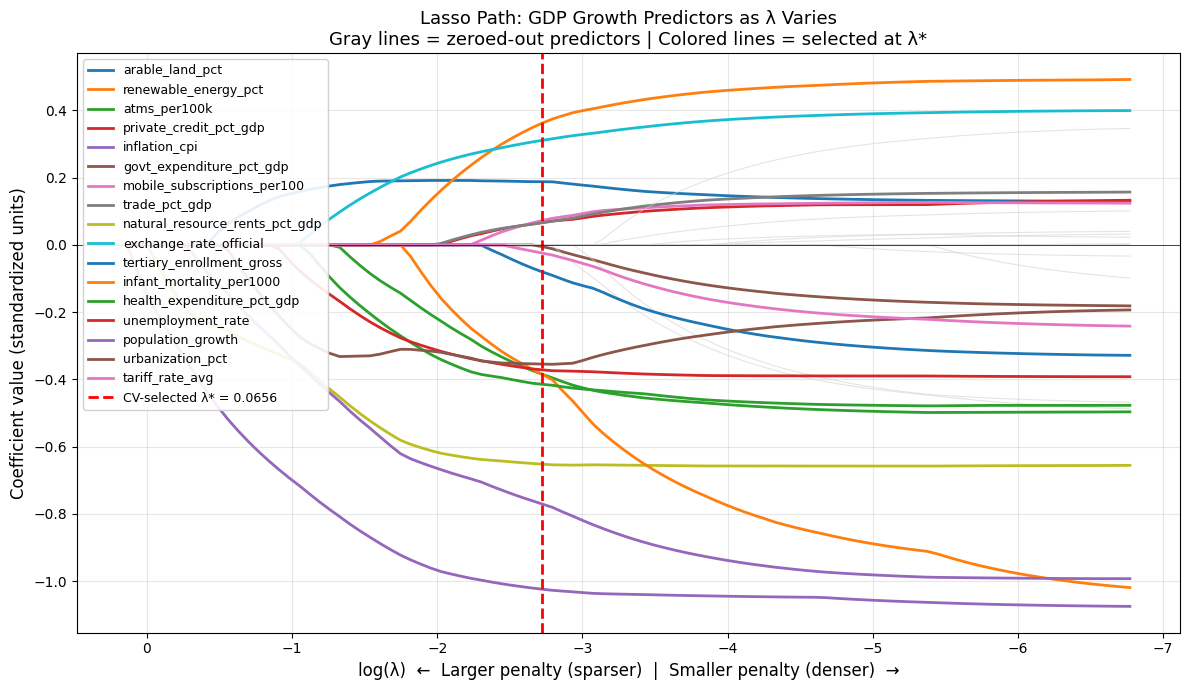

Lasso Path saved to lasso_path_gdp_growth.png


In [8]:
# ============================================================
# PART 2C: The Lasso Path — Who Enters First?
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100,
)

optimal_alpha = lasso_cv_model.alpha_

fig, ax = plt.subplots(figsize=(12, 7))

active_features_idx = np.where(lasso_cv_model.coef_ != 0)[0]

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('log(λ)  ←  Larger penalty (sparser)  |  Smaller penalty (denser)  →',
               fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray lines = zeroed-out predictors | Colored lines = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lasso_path_gdp_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Lasso Path saved to lasso_path_gdp_growth.png")

In [9]:
# ============================================================
# PART 2D: Model Comparison Table
# ============================================================

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge (RidgeCV)', 'Lasso (LassoCV)'],
    'Lambda (α*)': [
        'N/A (no penalty)',
        f'{ridge_cv.alpha_:.4f}',
        f'{lasso_cv_model.alpha_:.4f}'
    ],
    'Non-zero Predictors': [
        X_train.shape[1],
        X_train.shape[1],
        np.sum(lasso_cv_model.coef_ != 0)
    ],
    'Training R²': [
        f'{r2_score(y_train, ols_model.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, ridge_cv.predict(X_train_scaled)):.3f}',
        f'{r2_score(y_train, lasso_cv_model.predict(X_train_scaled)):.3f}'
    ],
    'Test R²': [
        f'{ols_test_r2:.3f}',
        f'{ridge_test_r2:.3f}',
        f'{lasso_test_r2:.3f}'
    ],
    'Test MSE': [
        f'{ols_test_mse:.3f}',
        f'{ridge_test_mse:.3f}',
        f'{lasso_test_mse:.3f}'
    ]
})

print(comparison.to_string(index=False))
print()
print("Key observations:")
print(f"  • OLS training R² >> test R²: evidence of overfitting (high variance)")
print(f"  • Ridge and Lasso reduce the train-test gap")
print(f"  • Lasso selects only {np.sum(lasso_cv_model.coef_ != 0)} of {X_train.shape[1]} predictors")
print(f"  • The other {X_train.shape[1] - np.sum(lasso_cv_model.coef_ != 0)} are predictively redundant,")
print(f"    not necessarily economically unimportant")

         Method      Lambda (α*)  Non-zero Predictors Training R² Test R² Test MSE
            OLS N/A (no penalty)                   28       0.600  -0.849    8.252
Ridge (RidgeCV)          47.1487                   28       0.557  -0.051    4.691
Lasso (LassoCV)           0.0656                   17       0.569  -0.330    5.934

Key observations:
  • OLS training R² >> test R²: evidence of overfitting (high variance)
  • Ridge and Lasso reduce the train-test gap
  • Lasso selects only 17 of 28 predictors
  • The other 11 are predictively redundant,
    not necessarily economically unimportant


Step 10: Open-Ended Interpretation (Written Responses)

Question 1: The reason that he is wrong is mainly due to Lasso is a prediction tool instead of a causation tool, which it requires experimental design or a causality identification strategy. To be specific, when the coeffieicient of paved_roads_pct is zero, it does not represent that paving road is an economically-less action to the contribution of the GDP. In detail, there is a strong correlation structure within the WDI index, which road-paving and other related populazing rate are refering to the performance of a country’s infrastructure. While the property of Lasso result in only capturing one or part of the variable, since it is enough to capture the behind-the-scenes information and showcase the accuracy, thus resetting it to zero. This is also the idea of conditional predictive redundancy, which is the extra prediction information is close to zero due to the existence of other variables. In other words, it does not represent there is a lack of causal relationship existence between road-paving and GDP growth,


Question 2: If I can choose only one between Ridge or Lasso, I would choose Ridge. The reason is due to the property of Ridge and Lasso. Since Lasso would kept some of the variable and drop the other variable if they are similar, which lead to instability and likely impact on our result. Considering the property of our data, there are high correlation between the prediction variable and a high p/n ratio. At the same time, Ridge is in a more even way. However, looking into the result, the R square for Lasso also reached a similar test result. Therefore, I would choose Ridge for this, while combining looking at the both Ridge and Lasso would be more helpful.

# AI Extension

In [15]:
"""
Interactive Plotly Dashboard: Lasso Path Explorer + Model Coefficient Comparison
================================================================================
Matches Lab 16 variable names:
    - X_train_scaled, X_test_scaled, y_train, y_test, feature_names
    - ols_model, ridge_cv, lasso_cv_model

Paste this cell after Part 2D in your Colab notebook.
"""

# ============================================================
# EXTENSION: Interactive Plotly Dashboard
# ============================================================
!pip install plotly -q

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.linear_model import lasso_path
from sklearn.metrics import r2_score

# ============================================================
# 1.  COMPUTE THE LASSO PATH
# ============================================================
alphas_grid = np.logspace(-4, 1, 200)
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    alphas=alphas_grid,
    max_iter=10_000,
)
n_features, n_alphas = coefs_path.shape
print(f"Lasso path computed: {n_features} features x {n_alphas} lambda values")

# ============================================================
# 2.  PRECOMPUTE R-SQUARED AT EVERY LAMBDA
# ============================================================
# At each alpha, predictions = X @ beta + mean(y_train).
# StandardScaler centres features, so the intercept equals y_train mean.

y_train_mean = np.mean(y_train)

r2_train_path = np.array([
    r2_score(y_train, X_train_scaled @ coefs_path[:, i] + y_train_mean)
    for i in range(n_alphas)
])
r2_test_path = np.array([
    r2_score(y_test, X_test_scaled @ coefs_path[:, i] + y_train_mean)
    for i in range(n_alphas)
])

# ============================================================
# 3.  CREATE SHORT LABELS (prevent axis-label overlap)
# ============================================================
short_names = []
for fn in feature_names:
    s = fn.replace('_pct_gdp', '%GDP').replace('_pct', '%') \
         .replace('_per100k', '/100k').replace('_per1000', '/1k') \
         .replace('_per100', '/100').replace('_rate', '_rt') \
         .replace('expenditure', 'expend').replace('subscriptions', 'subs') \
         .replace('enrollment', 'enroll').replace('official', 'offcl')
    short_names.append(s)

# ============================================================
# 4.  BUILD THE TWO-PANEL SUBPLOT LAYOUT
# ============================================================
# make_subplots creates a 1-row x 2-column grid.
# Each cell gets independent x/y axes.
# subplot_titles become annotations[0] and annotations[1] automatically.

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Lasso Coefficient Path  (drag slider to pick lambda)",
        "Coefficient Magnitudes: OLS vs Ridge vs Lasso",
    ),
    column_widths=[0.52, 0.48],
    horizontal_spacing=0.10,           # wider gap between panels
)

# ============================================================
# 5.  PANEL 1 — LASSO PATH TRACES
# ============================================================
# Each feature gets its own line.  Only the top-8 by peak |beta|
# are shown in the legend to avoid clutter; the rest are faint grey.

max_abs = np.max(np.abs(coefs_path), axis=1)
top_k = 8
top_indices = set(np.argsort(max_abs)[-top_k:])

palette = [
    "#636EFA", "#EF553B", "#00CC96", "#AB63FA",
    "#FFA15A", "#19D3F3", "#FF6692", "#B6E880",
]

color_i = 0
for j in range(n_features):
    is_top = j in top_indices
    if is_top:
        c = palette[color_i % len(palette)]
        color_i += 1
    else:
        c = "rgba(180,180,180,0.30)"

    fig.add_trace(
        go.Scatter(
            x=np.log10(alphas_path),
            y=coefs_path[j, :],
            mode="lines",
            name=short_names[j] if is_top else "",
            showlegend=is_top,
            line=dict(width=2.5 if is_top else 0.6, color=c),
            hovertemplate=(
                f"<b>{feature_names[j]}</b><br>"
                "log10(lambda)=%{x:.2f}<br>beta=%{y:.4f}<extra></extra>"
            ),
        ),
        row=1, col=1,
    )

# Dashed red vertical line at LassoCV optimal alpha
best_log_alpha = np.log10(lasso_cv_model.alpha_)
fig.add_vline(
    x=best_log_alpha, row=1, col=1,
    line=dict(color="red", width=2, dash="dash"),
    annotation_text=f"CV alpha*={lasso_cv_model.alpha_:.4f}",
    annotation_position="top left",
    annotation_font_size=10,
)

fig.update_xaxes(title_text="log10(lambda)", row=1, col=1)
fig.update_yaxes(title_text="Coefficient value (beta)", row=1, col=1)

# ============================================================
# 6.  PANEL 2 — GROUPED BAR CHART
# ============================================================
# Extract fitted .coef_ from each model object.
# scikit-learn stores them as 1-D arrays aligned with feature_names.
#   ols_model      -> .coef_
#   ridge_cv       -> .coef_   (RidgeCV from Lab 16)
#   lasso_cv_model -> .coef_   (LassoCV from Lab 16)

ols_coefs   = ols_model.coef_
ridge_coefs = ridge_cv.coef_
lasso_coefs = lasso_cv_model.coef_

# Sort by OLS |beta| descending; show top 15 to keep bars readable
sort_idx   = np.argsort(np.abs(ols_coefs))[::-1]
top_n_bars = 15
idx        = sort_idx[:top_n_bars]
bar_names  = [short_names[i] for i in idx]

# Three grouped bars per feature — one per model
for label, coefs, colour in [
    ("OLS",   ols_coefs[idx],   "#636EFA"),
    ("Ridge", ridge_coefs[idx], "#EF553B"),
    ("Lasso", lasso_coefs[idx], "#00CC96"),
]:
    fig.add_trace(
        go.Bar(
            x=bar_names,
            y=coefs,
            name=label,
            marker_color=colour,
            hovertemplate=(
                f"<b>{label}</b><br>"
                "%{x}<br>beta = %{y:.4f}<extra></extra>"
            ),
        ),
        row=1, col=2,
    )

fig.update_xaxes(
    title_text="Feature (sorted by |OLS beta|)",
    tickangle=-50,                     # steeper angle to avoid overlap
    tickfont_size=9,                   # smaller font for long labels
    row=1, col=2,
)
fig.update_yaxes(title_text="Coefficient value (beta)", row=1, col=2)
fig.update_layout(barmode="group")     # side-by-side bars

# ============================================================
# 7.  INTERACTIVE SLIDER
# ============================================================
# HOW THE PLOTLY SLIDER CALLBACK WORKS
# ─────────────────────────────────────
# Plotly in Python has no live Python callback at runtime.
# Instead we pre-build one layout update ("step") per slider position.
# When the user drags the slider, Plotly's JavaScript runtime swaps to
# the matching step, which:
#   (a) moves an orange dotted vertical line (a layout "shape")
#   (b) rewrites a text annotation showing Train R2, Test R2, and
#       the number of non-zero coefficients at that lambda.
#
# ~30 sample points keeps the JSON small while feeling responsive.

sample_step    = max(1, n_alphas // 30)
slider_indices = list(range(0, n_alphas, sample_step))

steps = []
for si in slider_indices:
    log_a     = np.log10(alphas_path[si])
    r2_tr     = r2_train_path[si]
    r2_te     = r2_test_path[si]
    n_nonzero = int(np.sum(np.abs(coefs_path[:, si]) > 1e-8))

    # method="relayout" only touches layout (shapes + annotations),
    # NOT the data traces — this is why the slider feels instant.
    step = dict(
        method="relayout",
        label=f"{log_a:.1f}",          # 1 decimal place keeps ticks short
        args=[{
            # --- move the vertical marker line ---
            "shapes[0].x0": log_a,
            "shapes[0].x1": log_a,
            # --- rewrite the floating R2 annotation ---
            # annotations[0] and [1] are subplot titles (auto-created);
            # annotations[2] is our custom R2 readout.
            "annotations[2].text": (
                f"<b>lambda = {alphas_path[si]:.4f}</b>  |  "
                f"R2 train = {r2_tr:.3f}  |  "
                f"R2 test = {r2_te:.3f}  |  "
                f"Non-zero: {n_nonzero}/{n_features}"
            ),
        }],
    )
    steps.append(step)

# Initial state (slider starts at midpoint)
init_pos   = len(slider_indices) // 2
init_idx   = slider_indices[init_pos]
init_log_a = np.log10(alphas_path[init_idx])

slider = dict(
    active=init_pos,
    currentvalue=dict(
        prefix="log10(lambda) = ",
        visible=True,
        font=dict(size=13),
    ),
    pad=dict(t=50, b=10),
    len=0.50,                          # slider spans 50% width (left panel)
    x=0.0,                             # left-aligned
    xanchor="left",
    steps=steps,
    ticklen=4,
    minorticklen=0,
)

fig.update_layout(
    # shapes[0]: orange vertical marker line in Panel 1
    shapes=[
        dict(
            type="line",
            x0=init_log_a, x1=init_log_a,
            y0=0, y1=1,
            xref="x", yref="y domain",  # y spans full panel height
            line=dict(color="orange", width=2, dash="dot"),
        )
    ],
    # annotations[0],[1] = subplot titles (auto-created by make_subplots)
    # annotations[2]     = our dynamic R2 readout below the path panel
    annotations=list(fig.layout.annotations) + [
        dict(
            text=(
                f"<b>lambda = {alphas_path[init_idx]:.4f}</b>  |  "
                f"R2 train = {r2_train_path[init_idx]:.3f}  |  "
                f"R2 test = {r2_test_path[init_idx]:.3f}  |  "
                f"Non-zero: "
                f"{int(np.sum(np.abs(coefs_path[:, init_idx]) > 1e-8))}"
                f"/{n_features}"
            ),
            xref="paper", yref="paper",
            x=0.0, y=-0.22,           # below slider, left-aligned
            xanchor="left",
            showarrow=False,
            font=dict(size=12, color="#E67E22"),
        )
    ],
    sliders=[slider],
)

# ============================================================
# 8.  GLOBAL LAYOUT POLISH
# ============================================================
fig.update_layout(
    height=700,                        # taller to avoid vertical cramping
    width=1350,
    title_text=(
        "Lab 16 -- WDI Regularisation Dashboard: "
        "Lasso Path & Coefficient Comparison"
    ),
    title_font_size=16,
    title_y=0.98,
    # Legend: vertical layout inside top-left of Panel 1
    legend=dict(
        orientation="v",
        yanchor="top", y=0.95,
        xanchor="left", x=0.01,
        font_size=9,
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor="rgba(200,200,200,0.5)",
        borderwidth=1,
    ),
    template="plotly_white",
    margin=dict(
        l=60, r=30,
        t=80,                          # room for title
        b=200,                         # room for slider + rotated labels
    ),
)

fig.show()

# ============================================================
# 9.  SUMMARY TABLE
# ============================================================
print("\n" + "=" * 62)
print("MODEL COMPARISON SUMMARY")
print("=" * 62)
print(f"{'Model':<18} {'lambda*':>10} {'Train R2':>10} {'Test R2':>10} {'Non-zero':>10}")
print("-" * 62)
for name, mdl, alpha_str in [
    ("OLS",   ols_model,      "     --"),
    ("Ridge", ridge_cv,       f"{ridge_cv.alpha_:>10.4f}"),
    ("Lasso", lasso_cv_model, f"{lasso_cv_model.alpha_:>10.4f}"),
]:
    tr = r2_score(y_train, mdl.predict(X_train_scaled))
    te = r2_score(y_test,  mdl.predict(X_test_scaled))
    nz = int(np.sum(np.abs(mdl.coef_) > 1e-8))
    print(f"{name:<18} {alpha_str} {tr:>10.4f} {te:>10.4f} {nz:>10}")
print("=" * 62)

Lasso path computed: 28 features x 200 lambda values



MODEL COMPARISON SUMMARY
Model                 lambda*   Train R2    Test R2   Non-zero
--------------------------------------------------------------
OLS                     --     0.5996    -0.8491         28
Ridge                 47.1487     0.5567    -0.0511         28
Lasso                  0.0656     0.5692    -0.3296         17
